In [46]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\B\raw_data.csv")

cols = data.columns[:-1].to_list() 

whole = data.copy()

data = whole.iloc[0:100,:]

# data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

validation = whole.iloc[100:200,:]

# validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()

# print(len(whole))
# print(len(data))
# print(len(validation))
print(data)

          X1        X2        X3        X4        X5        X6        X7  \
0   0.496714  0.538695 -0.138264 -0.134508  0.647689  0.616281  1.523030   
1  -0.234137 -0.206398  1.579213  1.566331  0.767435  0.783534 -0.469474   
2  -0.463418 -0.461629 -0.465730 -0.462061  0.241962  0.277533 -1.913280   
3  -0.562288 -0.581696 -1.012831 -0.996532  0.314247  0.335816 -0.908024   
4   1.465649  1.486595 -0.225776 -0.224310  0.067528  0.097410 -1.424748   
..       ...       ...       ...       ...       ...       ...       ...   
95 -0.249036 -0.251458  0.576557  0.573590  0.311250  0.371433  3.078881   
96 -0.127918 -0.125559 -0.955540 -0.927968 -1.606446 -1.544601  0.203464   
97 -1.422254 -1.482200 -0.646573 -0.655281 -1.081548 -1.045297  1.687142   
98 -0.007973  0.019517  1.479944  1.487966  0.077368  0.108090 -0.861284   
99  0.538910  0.549305 -1.037246 -1.027595 -0.190339 -0.172563 -0.875618   

          X8        X9       X10         Y  
0   1.517543 -0.234153 -0.177118 -0.032517

In [47]:
X = data[cols]

XTX = X.T @ X

y = data["Y"]

# beta
beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("手算:")
print(beta)
print("---------------------------------------------")

# 用套件驗證
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          # 不加 constant
)

result = model.fit()

print("套件驗證:")
print(result.params)

手算:
0    4.148882
1   -2.499832
2   -0.740905
3    2.529183
4    5.567521
5   -5.599912
6   -1.402776
7    1.519739
8    0.653170
9   -0.768639
dtype: float64
---------------------------------------------
套件驗證:
X1     4.148882
X2    -2.499832
X3    -0.740905
X4     2.529183
X5     5.567521
X6    -5.599912
X7    -1.402776
X8     1.519739
X9     0.653170
X10   -0.768639
dtype: float64


In [48]:
import torch

X = torch.tensor(
    data[cols].values,
    dtype=torch.float32
)

y = torch.tensor(
    data["Y"].values,
    dtype=torch.float32
)

# y_true = y.mean()

# y_true = y_true.reshape(1,1)

N = X.shape[0]
P = X.shape[1]

In [49]:
y

tensor([-0.0325,  2.2801, -2.5065, -3.1635,  0.2463, -1.6361,  2.2569, -2.6867,
         2.3267, -1.1038, -1.8088, -0.6531, -1.9779,  1.3222,  4.3311,  1.4657,
        -0.0643, -1.3804,  2.5628, -3.3507, -3.2574,  4.4095, -2.0474, -0.8430,
        -3.3706,  2.3617, -0.7609,  2.6901,  3.0220, -1.3109,  1.9088,  0.9697,
         0.1738,  2.8349, -1.9788,  4.5091,  0.0093,  1.5501,  0.7298, -2.7048,
         0.9498, -1.2099,  2.5291,  0.1110, -0.0845,  3.2537, -0.9083, -2.5704,
        -1.9389, -1.2970,  0.2484,  0.5209, -2.5079,  0.3862, -1.3979,  0.2782,
         0.9319, -2.8237, -0.9881,  0.5666, -1.5684,  2.2991,  2.0396,  1.0923,
         1.5220, -0.7783, -4.2510, -1.8865,  0.4350, -1.1710,  4.2617, -0.5040,
         3.7632, -0.1485,  0.3401, -0.1539, -1.9206,  2.1587, -0.8386, -4.3915,
        -3.9534, -0.1766, -2.2617, -0.9117,  6.2768, -0.5864, -6.3574,  2.9265,
         0.1202,  3.3456,  1.9597, -1.2430,  4.2756, -0.4757, -3.5197,  0.5051,
        -1.2169, -4.9128,  1.0341, -0.01

In [50]:
X

tensor([[ 4.9671e-01,  5.3869e-01, -1.3826e-01, -1.3451e-01,  6.4769e-01,
          6.1628e-01,  1.5230e+00,  1.5175e+00, -2.3415e-01, -1.7712e-01],
        [-2.3414e-01, -2.0640e-01,  1.5792e+00,  1.5663e+00,  7.6743e-01,
          7.8353e-01, -4.6947e-01, -4.2823e-01,  5.4256e-01,  5.4074e-01],
        [-4.6342e-01, -4.6163e-01, -4.6573e-01, -4.6206e-01,  2.4196e-01,
          2.7753e-01, -1.9133e+00, -1.9327e+00, -1.7249e+00, -1.7462e+00],
        [-5.6229e-01, -5.8170e-01, -1.0128e+00, -9.9653e-01,  3.1425e-01,
          3.3582e-01, -9.0802e-01, -9.3200e-01, -1.4123e+00, -1.4577e+00],
        [ 1.4656e+00,  1.4866e+00, -2.2578e-01, -2.2431e-01,  6.7528e-02,
          9.7410e-02, -1.4247e+00, -1.4392e+00, -5.4438e-01, -5.9848e-01],
        [ 1.1092e-01,  1.2273e-01, -1.1510e+00, -1.1498e+00,  3.7570e-01,
          3.5299e-01, -6.0064e-01, -6.2924e-01, -2.9169e-01, -3.3922e-01],
        [-6.0171e-01, -5.7485e-01,  1.8523e+00,  1.8312e+00, -1.3497e-02,
         -5.6152e-02, -1.0577e+0

In [51]:
import torch.nn as nn

embedding_dim = len(data)
dk = 4

wq = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

wk = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

# 先不需要V
# wv = torch.randn(
#     embedding_dim,
#     embedding_dim,
#     requires_grad=True
# )

# proj = nn.Linear(
#     embedding_dim,
#     1
# )

# linear = nn.Linear(
#     P,
#     1
# )

In [52]:
optimizer = torch.optim.Adam(

    [wq,wk], # wv

    # +list(proj.parameters())

    # +list(linear.parameters()),

    lr=0.001

)

In [53]:
import numpy as np
import torch.nn.functional as F

lam = 1

p = X.shape[1]

I = torch.eye(
    p,
    dtype=X.dtype,
    device=X.device
)

loss_history = []

initial_attn = None

epochs = 1000

for epoch in range(epochs):

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    A = attn @ attn.T + lam * I

    # beta
    beta = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

    # V = wv @ E

    # delta_E = V @ attn

    # New_E = E + delta_E

    # z = proj(
    # New_E.T
    # )

    # z = z.reshape(1,-1)

    # y_hat = linear(z)

#    mse_loss = F.mse_loss(
#    y_hat,
#    y
#    )

#    lambda_attn=0.1

#    loss = (
#        mse_loss
#        +
#        lambda_attn *
#        torch.mean(attn**2)
#    )

    y_hat = X @ beta

    loss = F.mse_loss(
    y_hat,
    y
    )


    if epoch == 0:
        initial_attn = attn.detach().clone()

        # mean_initial_attn = initial_attn.mean(dim=0)

        # print(E.shape)

        # print(Q.shape)

        # print(K.shape)

        # print(scores.shape)

        # print(attn.shape)

        # print(V.shape)

        # print(delta_E.shape)

        # print(New_E.shape)

        # print(z.shape)

        print(y_hat.shape)
        
        print(y.shape)


    loss_history.append(
        loss.item()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    final_attn = attn.clone()
    
    A = attn @ attn.T + lam * I

    # beta
    beta1 = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

print("訓練完之後的beta:")
print(beta1)

# =====================
# Average attention matrix across all samples
# =====================

# mean_attn = final_attn.mean(dim=0)



torch.Size([100])
torch.Size([100])
訓練完之後的beta:
tensor([ 9.3101e-01,  7.2341e-01,  8.4670e-01,  9.2635e-01,  2.2897e-01,
        -2.5029e-01,  5.8566e-04,  1.1446e-01, -3.8090e-02, -9.0113e-02])


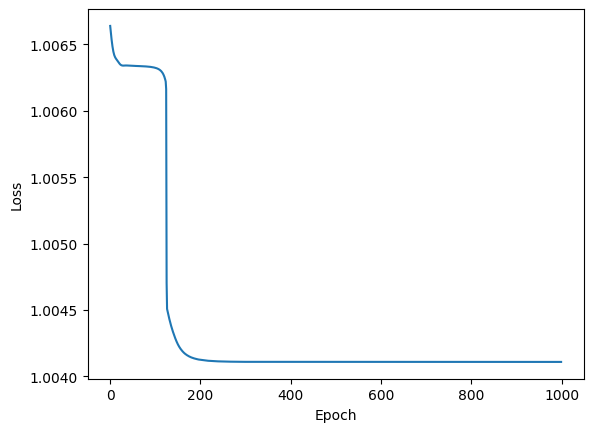

In [54]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

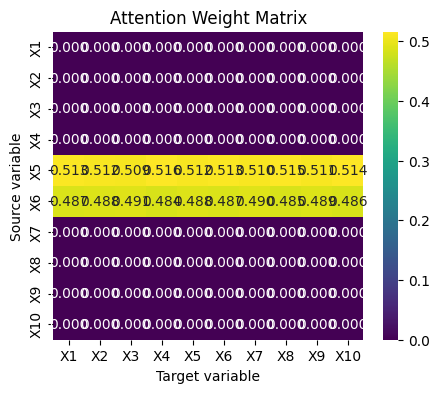

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
# 轉成 numpy
attn_matrix = final_attn.detach().numpy()

# 設定變數名稱
labels = cols

plt.figure(figsize=(5,4))

sns.heatmap(
    attn_matrix,
    annot=True,        # 顯示數值
    fmt=".3f",         # 小數三位
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis"
)

plt.xlabel("Target variable")
plt.ylabel("Source variable")
plt.title("Attention Weight Matrix")

plt.show()

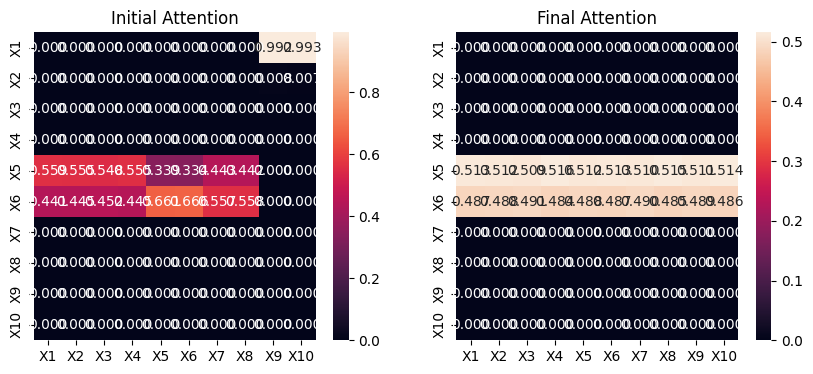

In [56]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()

In [57]:
beta_ols = result.params.values
beta_attn = beta1.detach().numpy()

In [58]:
print(beta_ols)
print(beta_attn)

[ 4.14888185 -2.49983194 -0.74090537  2.52918287  5.56752071 -5.5999121
 -1.40277597  1.51973892  0.65316978 -0.76863937]
[ 9.3101072e-01  7.2340560e-01  8.4670204e-01  9.2634785e-01
  2.2896639e-01 -2.5029424e-01  5.8565661e-04  1.1446159e-01
 -3.8089544e-02 -9.0113133e-02]


In [59]:
X_val = validation[cols].values
y_val = validation["Y"].values

y_pred_ols = X_val @ beta_ols

y_pred_attn = X_val @ beta_attn

In [60]:
from sklearn.metrics import mean_squared_error

mse_ols = mean_squared_error(
    y_val,
    y_pred_ols
)

mse_attn = mean_squared_error(
    y_val,
    y_pred_attn
)

print(f"OLS MSE = {mse_ols:.6f}")
print(f"Attention MSE = {mse_attn:.6f}")

OLS MSE = 1.279301
Attention MSE = 1.178634


In [61]:
rmse_ols = np.sqrt(mse_ols)
rmse_attn = np.sqrt(mse_attn)

print(f"OLS MSE = {rmse_ols:.6f}")
print(f"Attention MSE = {rmse_attn:.6f}")

OLS MSE = 1.131062
Attention MSE = 1.085649


In [62]:
from sklearn.metrics import r2_score

ols_r2 = r2_score(y_val, y_pred_ols)
attn_r2 = r2_score(y_val, y_pred_attn)

print(f"OLS R² = {ols_r2:.6f}")
print(f"Attention R² = {attn_r2:.6f}")

OLS R² = 0.841563
Attention R² = 0.854030


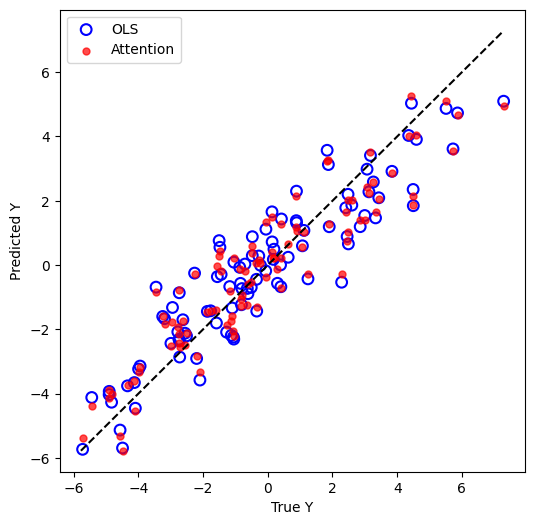

In [63]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_val,
    y_pred_ols,
    facecolors="none",
    edgecolors="blue",
    s=60,
    linewidth=1.5,
    label="OLS"
)

plt.scatter(
    y_val,
    y_pred_attn,
    color="red",
    s=25,
    alpha=0.7,
    label="Attention"
)

low = min(y_val.min(), y_pred_ols.min(), y_pred_attn.min())
high = max(y_val.max(), y_pred_ols.max(), y_pred_attn.max())

plt.plot([low, high], [low, high], "k--")

plt.xlabel("True Y")
plt.ylabel("Predicted Y")
plt.legend()
plt.show()